## Setup for EDA and time series 

In [43]:
#pip install xgboost

In [44]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Data Viz. 
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.ndimage import gaussian_filter
from calendar import monthrange
from calendar import month_name
from math import sqrt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf

from pmdarima.arima import auto_arima
import statsmodels.graphics.tsaplots as tsaplot
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing


from statsmodels.tsa.statespace.sarimax import SARIMAX
#New Libraries
#from statsmodels.tsa.statespace.sarimax import SARIMAX
sns.set_style(
    style='darkgrid', 
    rc={'axes.facecolor': 'white', 'grid.color': '.8'}
)
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'
cmaps_hex = ['#193251','#FF5A36','#696969', '#7589A2','#FF5A36', '#DB6668']
sns.set_palette(palette=cmaps_hex)
sns_c = sns.color_palette(palette=cmaps_hex)
%matplotlib inline
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [45]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [46]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,51459.25
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49988.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,49265.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48538.00
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48630.00


In [47]:
#res_df.dtypes

In [48]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

In [49]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()

In [50]:
#ycol_all_renw = ['total_energy_generation_mwh', 'solar_mwh', 'solar/energy_total','diff_total_energy_and_solar_mwh',
#             'wind_onshore_mwh','wind_offshore_mwh','waste_mwh','Solar_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']
#
#ycol_renw = ['wind_onshore_mwh','wind_offshore_mwh','waste_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']


#### Here we add new columns to data frame 

In [51]:

# Here we add new columns to data frame 
data_df_mwh['solar/Total_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['diff_total_energy_and_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']

# Total renewable energy column other than solar 
data_df_mwh['total_other_renewable_mwh'] = data_df_mwh['wind_onshore_mwh'] + data_df_mwh['wind_offshore_mwh'] + data_df_mwh['waste_mwh']
+ data_df_mwh['other_renewable_mwh'] + data_df_mwh['marine_mwh'] + data_df_mwh['hydro_run_of_river_and_poundage_mwh'] + data_df_mwh['hydro_water_reservoir_mwh'] + data_df_mwh['geothermal_mwh']
data_df_mwh.head()


,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh,solar/Total_energy,diff_total_energy_and_solar_mwh,total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


#### We capitalize the columns names

In [52]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

,Area,Mtu,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,...,Solar_mwh,Waste_mwh,Wind_offshore_mwh,Wind_onshore_mwh,Date,Hour,Total_energy_generation_mwh,Solar/total_energy,Diff_total_energy_and_solar_mwh,Total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [53]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [54]:
data_df_gwh = data_df_mwh.copy()

In [55]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [56]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [57]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [58]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [59]:
data_df_gwh.head()    

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [60]:

data_df= data_df_gwh.copy()

In [61]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [62]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [63]:
##data_df.columns

In [64]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [65]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files
#main_0  = 'Total_energy_generation_gwh' # This is only for energy
#title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy

main_0  = 'Solar_gwh' # for all other columns
title_main = main_0.replace('_', ' ').replace('gwh', 'energy in GWh')# for all other columns
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
#target = 'Total_energy_generation_gwh'
target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', '(GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Solar energy in GWh
Solar(GWh)


### Here we set the function for line plot  

In [66]:
def simple_lineplot(df, y, x='Date',time='Year'):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
   # try:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
   # except:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0, xlabel=time);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()



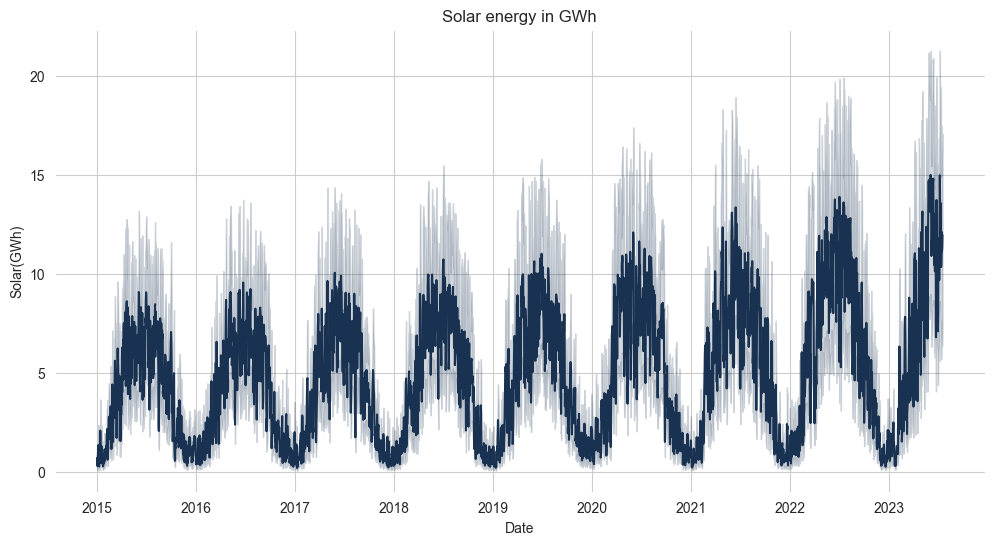

In [67]:
## Energy development over year (time)
fig, ax = plt.subplots()
sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
ax.set(title=title_main, ylabel= ylable_target);

In [68]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    simple_lineplot(df=data_df, y=col, x="Date", time='Year')

In [69]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [70]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

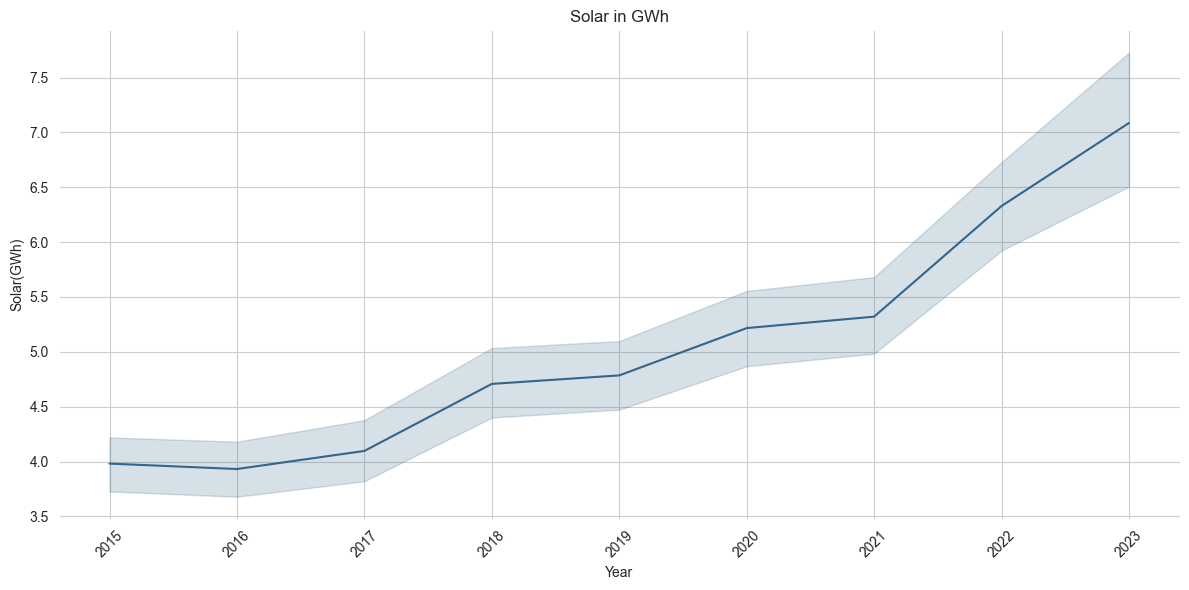

In [71]:
average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [72]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

In [73]:
daily_data_df

,Year,Month,Day,Dayofyear,Hour,Solar_gwh
Date,,,,,,
2015-01-01,2015,1,1,1,0,0.00000
2015-01-01,2015,1,1,1,1,0.00000
2015-01-01,2015,1,1,1,2,0.00000
2015-01-01,2015,1,1,1,3,0.00000
2015-01-01,2015,1,1,1,4,0.00000
...,...,...,...,...,...,...
2023-07-17,2023,7,17,198,18,10.08425
2023-07-17,2023,7,17,198,19,4.72400
2023-07-17,2023,7,17,198,20,1.51125


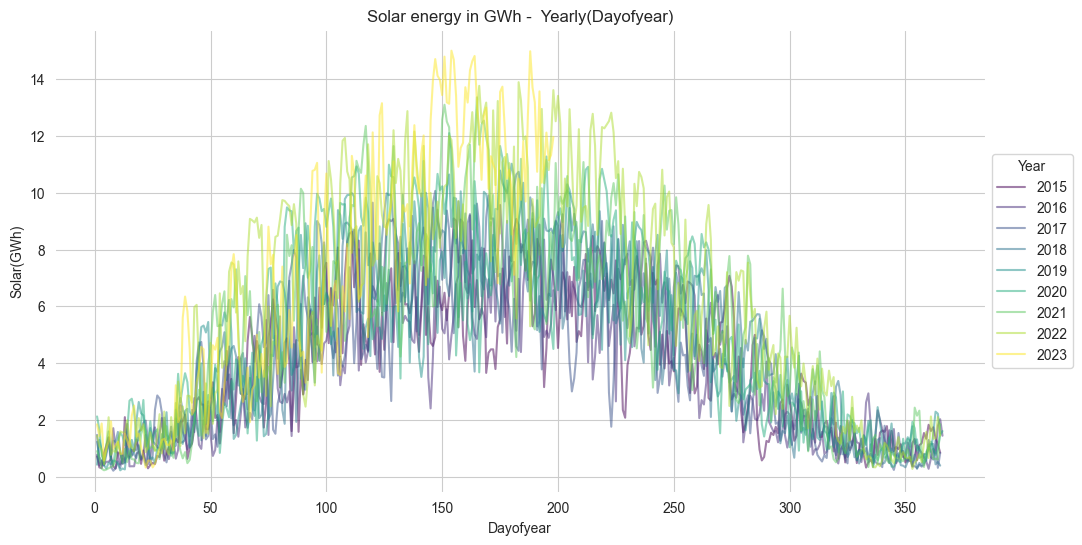

In [74]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [75]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Dayofyear', group='Year')

In [76]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr =  ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Month', group='Year')

In [77]:
# target = 'Solar_gwh'
# target1 = 'Total_energy_generation_gwh'
dfs = data_df[['Date', target]]
dfs.head(), dfs.columns

(        Date  Solar_gwh
 0 2015-01-01        0.0
 1 2015-01-01        0.0
 2 2015-01-01        0.0
 3 2015-01-01        0.0
 4 2015-01-01        0.0,
 Index(['Date', 'Solar_gwh'], dtype='object'))

In [80]:
def arima_model(data, target, lookback=12):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')

    X_arima = data[target].values

    train_size = int(len(X_arima) * 0.8)
    X_train_arima, X_test_arima = X_arima[:train_size], X_arima[train_size-lookback:]

    # Fit ARIMA model
    model = auto_arima(X_train_arima, seasonal=True, m=12, stepwise=True, suppress_warnings=True)
    model.fit(X_train_arima)

    # ARIMA prediction on test and train data
    y_pred_train_arima = model.predict_in_sample()
    y_pred_test_arima = model.predict(n_periods=len(X_test_arima))

    # Compute metrics for ARIMA
    train_rmse = np.sqrt(mean_squared_error(X_train_arima, y_pred_train_arima))
    test_rmse = np.sqrt(mean_squared_error(X_test_arima, y_pred_test_arima))
    train_mse = mean_squared_error(X_train_arima, y_pred_train_arima)
    test_mse = mean_squared_error(X_test_arima, y_pred_test_arima)
    train_mae = mean_absolute_error(X_train_arima, y_pred_train_arima)
    test_mae = mean_absolute_error(X_test_arima, y_pred_test_arima)
    train_r2 = r2_score(X_train_arima, y_pred_train_arima)
    test_r2 = r2_score(X_test_arima, y_pred_test_arima)

    # Calculate residuals
    residuals = X_test_arima - y_pred_test_arima

    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(X_test_arima, y_pred_test_arima, label='', color='blue')
    plt.plot([X_test_arima.min(), X_test_arima.max()], [X_test_arima.min(), X_test_arima.max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()

    # Plot actual, train data, and predicted test data for ARIMA
    plt.figure(figsize=(15, 5))
    train_index = data.index[:train_size][-len(X_train_arima):]
    test_index = data.index[train_size:]
    plt.plot(data.index, data[target], label='Historical Data', color='gray')
    plt.plot(train_index, X_train_arima, label='Train Data', color='blue')
    plt.plot(test_index, X_test_arima, label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_arima, label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_arima, label='Predicted Train Data', color='green', linestyle='dashed')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    print('X_train_arima.shape, X_test_arima.shape, data.shape =', X_train_arima.shape, X_test_arima.shape, data.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_arima,
    }

import pandas as pd

def detrend_data(data, window):
    # Convert the data to numeric and handle missing values
    data = pd.to_numeric(data, errors='coerce')
    data = data.fillna(method='bfill')

    # Calculate the rolling mean (detrended data)
    detrended = data.rolling(window=window, min_periods=1, center=True).mean()

    return detrended


def preprocess_data(data, target, freq='M', rolling_mean=None, detrend=False):
    df = data.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    if freq:
        df_resampled = df.resample(freq).mean()
    else:
        df_resampled = df

    if rolling_mean:
        df_resampled[target] = df_resampled[target].rolling(window=rolling_mean, min_periods=1, center=True).mean()
        df_resampled[target] = df_resampled[target].fillna(method='bfill')

    if detrend:
        result = seasonal_decompose(df_resampled[target], model='additive', period=12)
        df_resampled[target] = df_resampled[target] - result.trend
        df_resampled = df_resampled.dropna()

    # Plot seasonality, trend, detrend, and stationarity over time
    plt.figure(figsize=(15, 10))
    plt.subplot(4, 1, 1)
    plt.plot(df_resampled[target], label='Original Data', color='blue')
    plt.legend()
    plt.title('Original Data')

    plt.subplot(4, 1, 2)
    plt.plot(result.trend, label='Trend', color='red')
    plt.legend()
    plt.title('Trend')

    plt.subplot(4, 1, 3)
    plt.plot(result.seasonal, label='Seasonality', color='green')
    plt.legend()
    plt.title('Seasonality')

    plt.subplot(4, 1, 4)
    plt.plot(df_resampled[target], label='Detrended and Stationary Data', color='orange')
    plt.legend()
    plt.title('Detrended and Stationary Data')

    plt.tight_layout()
    plt.show()

    return df_resampled

In [81]:
# Set rolling mean window for detrending (e.g., window size of 5)
data = data_df.copy()
rolling_mean_window = 5
lookback=12
# Preprocess the data and visualize seasonality, trend, detrended data, and stationarity
preprocessed_data = preprocess_data(data, target, rolling_mean=rolling_mean_window, detrend=False)
# Perform ARIMA forecasting on the preprocessed data
#lookback = 12
forecast_results = arima_model(preprocessed_data, target, lookback=lookback)

TypeError: Could not convert Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE)Germany (DE

In [ ]:

# Example usage
data_df = pd.read_csv('your_data.csv')  # Replace 'your_data.csv' with your data file
target_column = 'Solar_gwh'

# Preprocess the data and visualize seasonality, trend, detrended data, and stationarity
preprocessed_data = preprocess_data(data_df, target_column, rolling_mean=5, detrend=True)

# Perform ARIMA forecasting on the preprocessed data
forecast_results = arima_model(preprocessed_data, target_column, lookback=12)


### Creating train and test sets
We will split our data and take the first part as our training set and the years after 2016 as a test set. Since we are dealing with a time series here we cannot split randomly as we are used to do. 

# Rolling mean  

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_74857/2123328380.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


([], [])

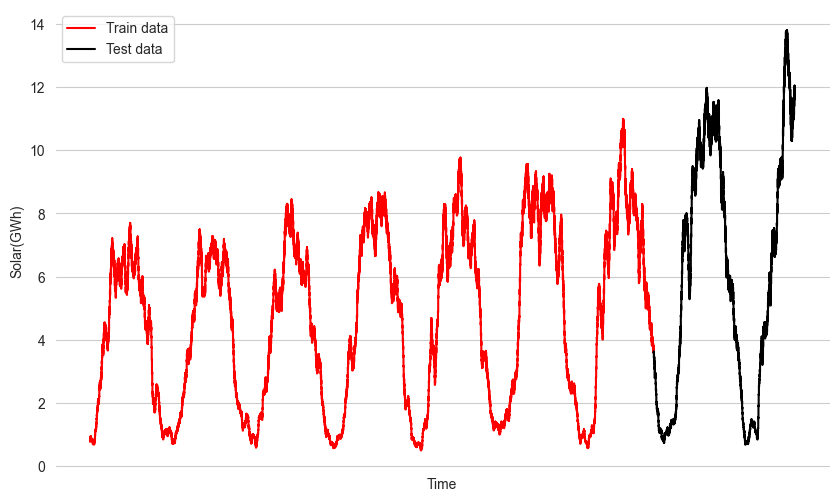

In [38]:
# Select the necessary columns 'Date' and the target column 'Your_Target_Column_Name'
# test  to see gap as welll

dfs = data_df[['Date', target]]

# Convert 'Date' column to datetime format and set it as the index
dfs['Date'] = pd.to_datetime(dfs['Date'])
dfs.set_index('Date', inplace=True)

# Resample data at a monthly frequency and aggregate using mean (you can choose other aggregation methods if needed)
#dfs_monthly = dfs.resample('M').mean()

# Calculate the rolling mean for the entire dataset
df_arima = dfs[target].rolling(window=30*12).mean()
df_arima = df_arima.dropna()

#df_arima = fs[target]

train_test_split_ratio = int(len(df_arima)*0.8)
train_data, test_data = df_arima[:train_test_split_ratio], df_arima[train_test_split_ratio:]

# Plotting the train and test set
plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.plot(train_data, 'red', label='Train data')
plt.plot(test_data, 'black', label='Test data')
plt.legend()
plt.xticks([])
#plt.xlim(pd.to_datet


In [39]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data,seasonal=True, m=4, scoring='mse', start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1,D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
#arima_model = auto_arima(train_data,start_p=1,start_q=1,test='adf',max_p=3,max_q=3,m=12,start_P=0,seasonal=True,d=None, D=1,trace=False
#                         ,error_action='ignore',suppress_warnings=True, stepwise=True)
#
arima_model = auto_arima(train_data,m=12, seasonal=True,
                      start_p=1, start_q=1, max_order=4, test='adf',error_action='ignore',  
                           suppress_warnings=True,
                      stepwise=True, trace=True)


# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.1) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted', color='#1f76b4')
plt.title(title_main )
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))
#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=-479991.190, Time=164.85 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-272369.156, Time=3.61 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-398955.154, Time=69.53 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-353486.496, Time=80.78 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-272370.935, Time=0.92 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=-468769.640, Time=157.60 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=-469901.047, Time=148.06 sec
 ARIMA(1,1,1)(2,0,1)[12] intercept   : AIC=-583459.533, Time=354.50 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=-583346.197, Time=177.89 sec
 ARIMA(1,1,1)(2,0,2)[12] intercept   : AIC=-590757.604, Time=544.20 sec


: 

: 

In [ ]:

#dfs['Date'] = pd.to_datetime(dfs['Date'])
#dfs.set_index('Date', inplace=True)
# Resample data at a monthly frequency and aggregate using mean (you can choose other aggregation methods if needed)
#dfs1 = dfs.resample('D').mean()

#df_arima = dfs1[target]

#train_test_split_ratio = int(len(df_arima)*0.8)
#train_data, test_data = df_arima[:train_test_split_ratio], df_arima[train_test_split_ratio:]
##
##
# Plotting the train and test set
#plt.figure(figsize=(10,6))
#plt.xlabel('Time')
#plt.ylabel(ylable_target)
#plt.plot(train_data, 'red', label='Train data')
#plt.plot(test_data, 'black', label='Test data')
#plt.legend()
#plt.xticks([])
#plt.xlim(pd.to_datetime("2015"),pd.to_datetime("2023"))


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_58372/2522620418.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


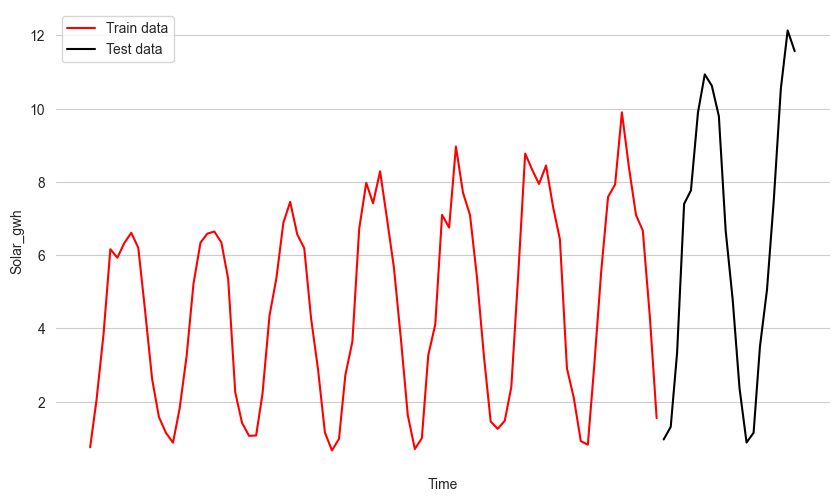

In [165]:
# Select the necessary columns 'Date' and the target column 'Your_Target_Column_Name'
# test  to see gap as welll

dfs = data_df[['Date', target]]

# Convert 'Date' column to datetime format and set it as the index
dfs['Date'] = pd.to_datetime(dfs['Date'])
dfs.set_index('Date', inplace=True)

# Resample data at a monthly frequency and aggregate using mean (you can choose other aggregation methods if needed)
dfs_monthly = dfs.resample('M').mean()

df_arima = dfs_monthly[target]

# Calculate the length of the test set (gap)
test_set_gap = int(len(df_arima) * 0.2)

# Calculate the index at which the test set starts
test_set_start_index = len(df_arima) - test_set_gap

# Split the data into train and test sets
train_data, test_data = df_arima.iloc[:test_set_start_index], df_arima.iloc[test_set_start_index:]

# Plotting the train and test set
plt.figure(figsize=(10, 6))
plt.xlabel('Time')
plt.ylabel(target)
plt.plot(train_data, 'red', label='Train data')
plt.plot(test_data, 'black', label='Test data')
plt.legend()
plt.xticks([])
plt.show()


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=inf, Time=6.12 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=210.879, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=165.063, Time=0.88 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=4.58 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=190.644, Time=0.02 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=166.863, Time=2.71 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=166.457, Time=1.27 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=167.094, Time=1.44 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=167.447, Time=11.18 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=182.661, Time=0.77 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=155.392, Time=1.18 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=181.473, Time=0.03 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=157.387, Time=3.28 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=157.383, Time=1.25 sec
 ARIMA(2,1,0)(0,1,1)[12]             : A

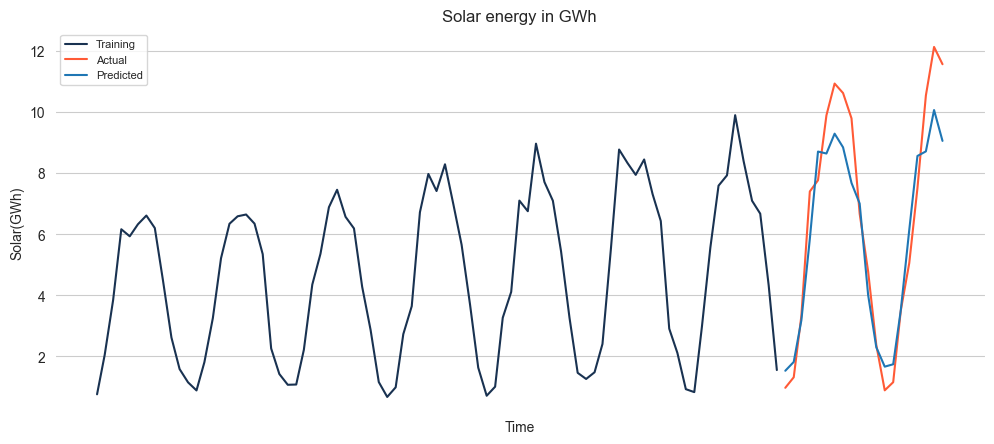

In [166]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data,seasonal=True, m=4, scoring='mse', start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1,D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
#arima_model = auto_arima(train_data,start_p=1,start_q=1,test='adf',max_p=3,max_q=3,m=12,start_P=0,seasonal=True,d=None, D=1,trace=False
#                         ,error_action='ignore',suppress_warnings=True, stepwise=True)
#
arima_model = auto_arima(train_data,m=12, seasonal=True,
                      start_p=1, start_q=1, max_order=4, test='adf',error_action='ignore',  
                           suppress_warnings=True,
                      stepwise=True, trace=True)


# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.1) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted', color='#1f76b4')
plt.title(title_main )
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))
#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   83
Model:             SARIMAX(3, 1, 0)x(1, 1, 0, 12)   Log Likelihood                 -70.914
Date:                            Tue, 01 Aug 2023   AIC                            151.827
Time:                                    21:17:55   BIC                            163.070
Sample:                                01-31-2015   HQIC                           156.293
                                     - 11-30-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8165      0.104     -7.848      0.000      -1.020      -0.613
ar.L2         -0.6066      0.148   

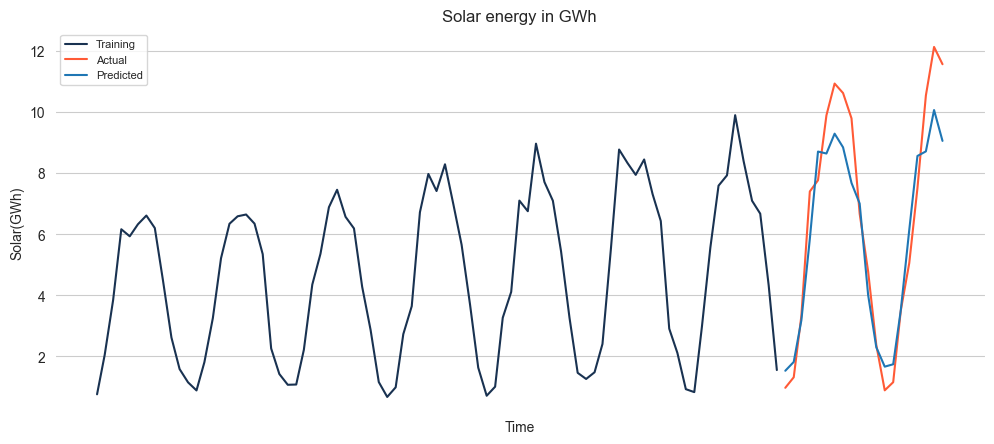

In [167]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data,seasonal=True, m=4, scoring='mse', start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1,D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
arima_model = auto_arima(train_data,start_p=1,start_q=1,test='adf',max_p=3,max_q=3,m=12,start_P=0,seasonal=True,d=None, D=1,trace=False
                         ,error_action='ignore',suppress_warnings=True, stepwise=True)
#
#arima_model = auto_arima(train_data,m=12, seasonal=True,
#                      start_p=1, start_q=1, max_order=4, test='adf',error_action='ignore',  
#                           suppress_warnings=True,
#                      stepwise=True, trace=True)


# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.1) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted', color='#1f76b4')
plt.title(title_main )
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))
#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   83
Model:             SARIMAX(3, 1, 0)x(1, 1, 0, 12)   Log Likelihood                 -70.914
Date:                            Tue, 01 Aug 2023   AIC                            151.827
Time:                                    21:20:24   BIC                            163.070
Sample:                                01-31-2015   HQIC                           156.293
                                     - 11-30-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8165      0.104     -7.848      0.000      -1.020      -0.613
ar.L2         -0.6066      0.148   

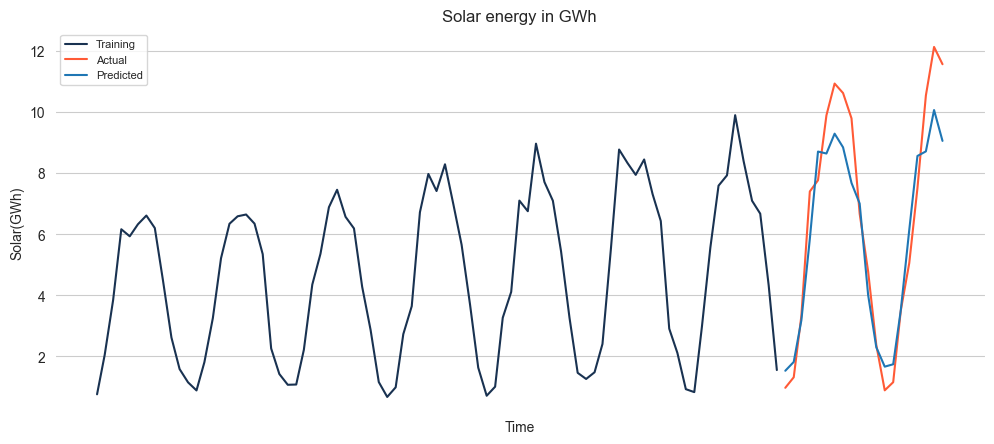

In [168]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data,seasonal=True, m=4, scoring='mse', start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1,D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
arima_model = auto_arima(train_data,start_p=1,start_q=1,test='adf',max_p=5,max_q=5,m=12,start_P=0,seasonal=True,d=None, D=1,trace=False
                         ,error_action='ignore',suppress_warnings=True, stepwise=True, alpha=0.01)
#
#arima_model = auto_arima(train_data,m=12, seasonal=True,
#                      start_p=1, start_q=1, max_order=4, test='adf',error_action='ignore',  
#                           suppress_warnings=True,
#                      stepwise=True, trace=True)


# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.01) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted', color='#1f76b4')
plt.title(title_main )
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))
#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

#### Daily resolution

In [169]:
# target = 'Solar_gwh'
# target1 = 'Total_energy_generation_gwh'
dfs = data_df[['Date', target]]
dfs.head(), dfs.columns

(        Date  Solar_gwh
 0 2015-01-01        0.0
 1 2015-01-01        0.0
 2 2015-01-01        0.0
 3 2015-01-01        0.0
 4 2015-01-01        0.0,
 Index(['Date', 'Solar_gwh'], dtype='object'))

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_58372/1239657723.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


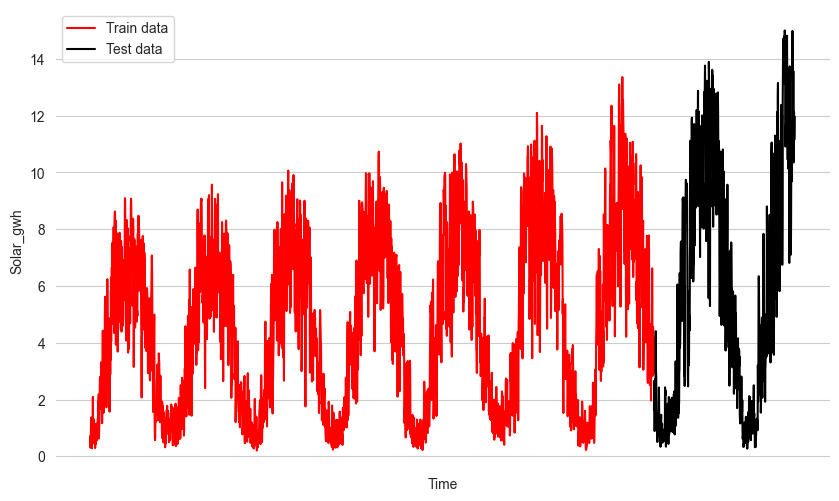

In [176]:
# Select the necessary columns 'Date' and the target column 'Your_Target_Column_Name'
#target = 'Your_Target_Column_Name'
target = 'Solar_gwh'
# target1 = 'Total_energy_generation_gwh'
dfs = data_df[['Date', target]]

# Convert 'Date' column to datetime format and set it as the index
dfs['Date'] = pd.to_datetime(dfs['Date'])
dfs.set_index('Date', inplace=True)

# Resample data at a daily frequency and aggregate using mean (you can choose other aggregation methods if needed)
dfs_daily = dfs.resample('D').mean()

df_arima = dfs_daily[target]

# Calculate the length of the test set (gap)
test_set_gap = int(len(df_arima) * 0.2)

# Calculate the index at which the test set starts
test_set_start_index = len(df_arima) - test_set_gap

# Split the data into train and test sets
train_data, test_data = df_arima.iloc[:test_set_start_index], df_arima.iloc[test_set_start_index:]

# Plotting the train and test set
plt.figure(figsize=(10, 6))
plt.xlabel('Time')
plt.ylabel(target)
plt.plot(train_data, 'red', label='Train data')
plt.plot(test_data, 'black', label='Test data')
plt.legend()
plt.xticks([])
plt.show()


In [177]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data,seasonal=True, m=4, scoring='mse', start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1,D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
arima_model = auto_arima(train_data,start_p=1,start_q=1,test='adf',max_p=3,max_q=3,m=30,start_P=0,seasonal=True,d=None, D=1,trace=False
                         ,error_action='ignore',suppress_warnings=True, stepwise=True)
#
#arima_model = auto_arima(train_data,m=12, seasonal=True,
#                      start_p=1, start_q=1, max_order=4, test='adf',error_action='ignore',  
#                           suppress_warnings=True,
#                      stepwise=True, trace=True)


# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.1) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted', color='#1f76b4')
plt.title(title_main )
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))
#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

: 

: 

                                       SARIMAX Results                                        
Dep. Variable:                                      y   No. Observations:                 2496
Model:             SARIMAX(0, 0, 3)x(2, 1, [1, 2], 7)   Log Likelihood               -4347.679
Date:                                Tue, 01 Aug 2023   AIC                           8711.358
Time:                                        22:02:36   BIC                           8757.916
Sample:                                    01-01-2015   HQIC                          8728.265
                                         - 10-31-2021                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.6225      0.017     36.011      0.000       0.589       0.656
ma.

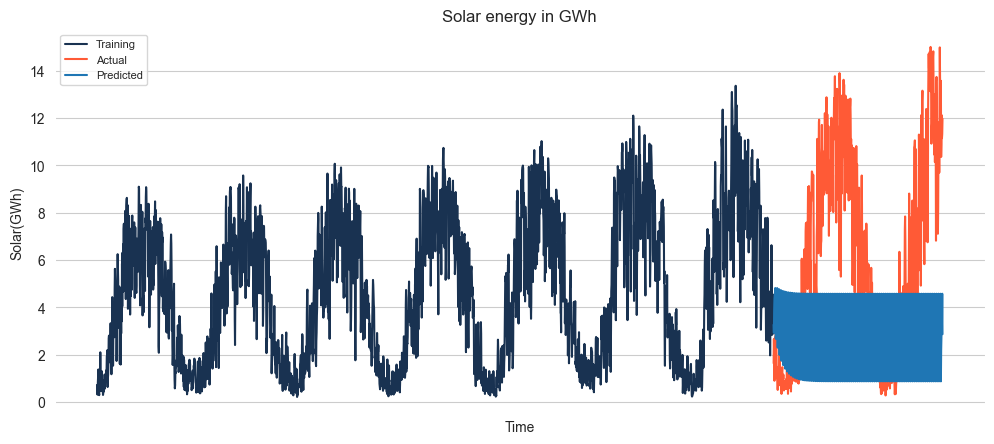

In [175]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data,seasonal=True, m=4, scoring='mse', start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1,D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
arima_model = auto_arima(train_data,start_p=1,start_q=1,test='adf',max_p=3,max_q=3,m=7,start_P=0,seasonal=True,d=None, D=1,trace=False
                         ,error_action='ignore',suppress_warnings=True, stepwise=True)
#
#arima_model = auto_arima(train_data,m=12, seasonal=True,
#                      start_p=1, start_q=1, max_order=4, test='adf',error_action='ignore',  
#                           suppress_warnings=True,
#                      stepwise=True, trace=True)


# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.1) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted', color='#1f76b4')
plt.title(title_main )
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))
#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_60027/3760869861.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Date'] = pd.to_datetime(dfs['Date'])


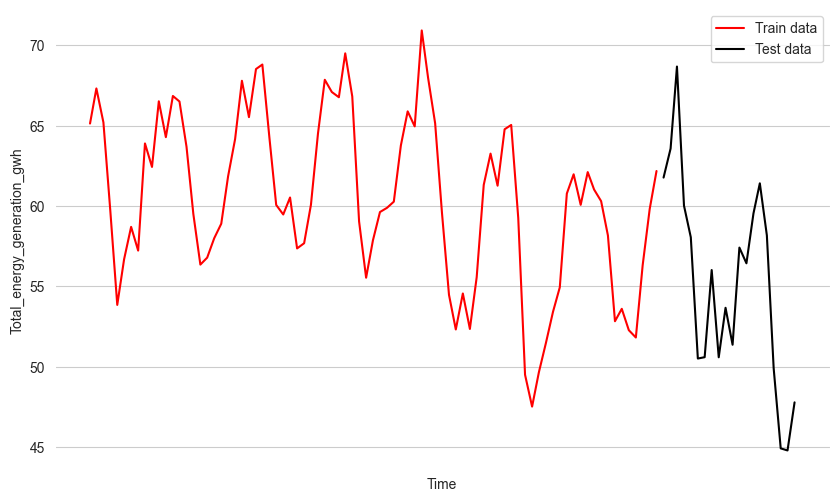

In [36]:
#target = 'Solar_gwh'
target = 'Total_energy_generation_gwh'
# Select the necessary columns 'Date' and the target column 'Your_Target_Column_Name'
# test  to see gap as welll

dfs = data_df[['Date', target]]

# Convert 'Date' column to datetime format and set it as the index
dfs['Date'] = pd.to_datetime(dfs['Date'])
dfs.set_index('Date', inplace=True)

# Resample data at a monthly frequency and aggregate using mean (you can choose other aggregation methods if needed)
dfs_monthly = dfs.resample('M').mean()

df_arima = dfs_monthly[target]

# Calculate the length of the test set (gap)
test_set_gap = int(len(df_arima) * 0.2)

# Calculate the index at which the test set starts
test_set_start_index = len(df_arima) - test_set_gap

# Split the data into train and test sets
train_data, test_data = df_arima.iloc[:test_set_start_index], df_arima.iloc[test_set_start_index:]

# Plotting the train and test set
plt.figure(figsize=(10, 6))
plt.xlabel('Time')
plt.ylabel(target)
plt.plot(train_data, 'red', label='Train data')
plt.plot(test_data, 'black', label='Test data')
plt.legend()
plt.xticks([])
plt.show()


                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                   83
Model:             SARIMAX(1, 1, 1)x(2, 1, [], 12)   Log Likelihood                -150.746
Date:                             Tue, 01 Aug 2023   AIC                            311.492
Time:                                     22:31:57   BIC                            322.734
Sample:                                 01-31-2015   HQIC                           315.957
                                      - 11-30-2021                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4338      0.254      1.709      0.088      -0.064       0.931
ma.L1         -0.7886      

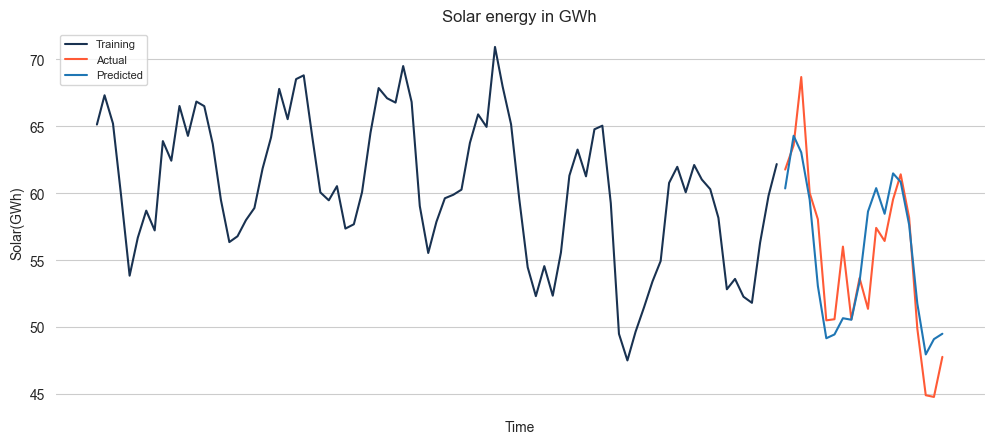

In [37]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data,seasonal=True, m=4, scoring='mse', start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1,D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
arima_model = auto_arima(train_data,start_p=1,start_q=1,test='adf',max_p=5,max_q=5,m=12
                         ,seasonal=True,d=None, D=1,trace=False
                         ,error_action='ignore',suppress_warnings=True, stepwise=True, alpha=0.01)
#
#arima_model = auto_arima(train_data,m=12, seasonal=True,
#                      start_p=1, start_q=1, max_order=4, test='adf',error_action='ignore',  
#                           suppress_warnings=True,
#                      stepwise=True, trace=True)


# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.01) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted', color='#1f76b4')
plt.title(title_main )
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))
#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   83
Model:             SARIMAX(5, 0, 0)x(2, 1, 0, 15)   Log Likelihood                -177.193
Date:                            Tue, 01 Aug 2023   AIC                            372.385
Time:                                    22:38:16   BIC                            392.361
Sample:                                01-31-2015   HQIC                           380.300
                                     - 11-30-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.7915      0.671     -2.672      0.008      -3.106      -0.477
ar.L1          0.8870      0.146   

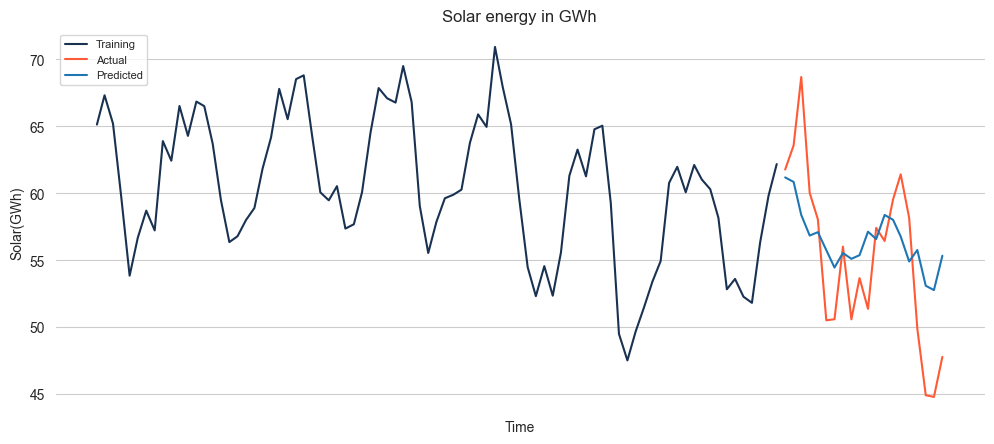

In [41]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data,seasonal=True, m=4, scoring='mse', start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1,D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
arima_model = auto_arima(train_data,start_p=1,start_q=1,test='adf',max_p=5,max_q=5,m=20,start_P=1,start_1=1,max_P=5,max_Q=5
                         ,seasonal=True,d=None, D=1,trace=False, max_order=12
                         ,error_action='ignore',suppress_warnings=True, stepwise=True, alpha=0.01)
#
#arima_model = auto_arima(train_data,m=12, seasonal=True,
#                      start_p=1, start_q=1, max_order=4, test='adf',error_action='ignore',  
#                           suppress_warnings=True,
#                      stepwise=True, trace=True)


# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.01) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted', color='#1f76b4')
plt.title(title_main )
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))
#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

- In seasonal auto_arima, the parameter m represents the number of periods in each season for the time series data. For daily sampling, you may choose the value of m based on the seasonality you expect in the data.

- For daily data, the value of m typically corresponds to the number of days in a seasonal cycle. For example:

- If you expect weekly seasonality in your data, you can set m=7 (7 days in a week).

- If you expect monthly seasonality, you can set m=30 or m=31 (depending on the number of days in your month).

- It's essential to analyze the data and understand the seasonality patterns before deciding the appropriate value of m. You can use techniques like autocorrelation plots (ACF) and partial autocorrelation plots (PACF) to help identify the seasonality and determine the value of m.

- Keep in mind that seasonal auto_arima automatically tries different values of m during the model selection process and chooses the one that provides the best fit based on the selected information criteria (e.g., AIC, BIC). However, providing an appropriate m value based on your domain knowledge can guide the model selection process and potentially lead to better results.


